In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# ==========================================
# [실험 설정 구간] 모든 하이퍼파라미터 통합 
# ==========================================
DATA_PATH = './CMAPSSData/'
CONFIG = {
    'DATA_ID': 'FD001',
    'RUL_CAP': 125,
    'GAUSS_SIGMA': 2,
    'RANDOM_STATE': 42,
    'TEST_SIZE': 0.2,
    'SCALER_TYPE': 'minmax',  # minmax , Standard
    
    # 사용할 센서 직접 지정 (상수 센서 자동 감지 대신 사용)
    'BASE_SENSORS': ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 
                     's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21'],
    'SETTING_FEATURES': ['setting_1', 'setting_2', 'setting_3'],

    # 파생변수 설정 (리스트 형식 지원)
    'USE_MA': True,   'WIN_MA': [3, 5],
    'USE_STD': True,  'WIN_STD': [5, 10],  
    'USE_DIFF': True, 'PER_DIFF': [1],
    'USE_EMA': True,  'SPAN_EMA': [3, 5, 10],
    'USE_LAG': True,  'LAG_STEP': [1, 3, 5, 10],
}

# ---------------------------------------------------------
# [1] 데이터 로드 및 초기 전처리 (Capping & 상수 제거)
# ---------------------------------------------------------
def load_and_basic_prep(config):
    # 전체 컬럼 정의
    cols = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
    
    # 데이터 로드
    train = pd.read_csv(f"{DATA_PATH}train_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
    test = pd.read_csv(f"{DATA_PATH}test_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
    y_test_final = pd.read_csv(f"{DATA_PATH}RUL_{config['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values

    # RUL 생성 및 Capping
    train['max_cycle'] = train.groupby('unit_nr')['time_cycles'].transform('max')
    train['RUL'] = (train['max_cycle'] - train['time_cycles']).clip(upper=config['RUL_CAP'])
    train.drop(columns=['max_cycle'], inplace=True)

    # 명시적으로 선택한 컬럼만 유지 (unit_nr, time_cycles, RUL + 선택 센서 + 세팅값)
    keep_cols = ['unit_nr', 'time_cycles'] + config['SETTING_FEATURES'] + config['BASE_SENSORS']
    
    # Train은 RUL 포함, Test는 RUL 제외하고 선택
    train = train[keep_cols + ['RUL']]
    test = test[keep_cols]
    
    print(f" 센서 선택 완료: {config['BASE_SENSORS']}")
    print(f" 유지된 컬럼 총 {len(train.columns)}개 (RUL 포함)")
    
    return train, test, y_test_final

# 실행 
df_train, df_test, y_test = load_and_basic_prep(CONFIG)

# ---------------------------------------------------------
# [2] 가우시안 스무딩 (Team Style)
# ---------------------------------------------------------
def apply_gaussian_smoothing(df, sigma):
    if sigma <= 0: return df.copy()
    df = df.copy().sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
    sensors = [c for c in df.columns if c.startswith('s_')]
    
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for col in sensors:
            arr = df.loc[mask, col].to_numpy(dtype=np.float32)
            df.loc[mask, col] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')
    return df

df_train = apply_gaussian_smoothing(df_train, CONFIG['GAUSS_SIGMA'])
df_test = apply_gaussian_smoothing(df_test, CONFIG['GAUSS_SIGMA'])
print(f"✅ 가우시안 스무딩 완료 (Sigma: {CONFIG['GAUSS_SIGMA']})")

# ---------------------------------------------------------
# [3] 데이터 분할 (Train / Val)
# ---------------------------------------------------------
unit_ids = df_train['unit_nr'].unique()
train_units, val_units = train_test_split(unit_ids, test_size=CONFIG['TEST_SIZE'], random_state=CONFIG['RANDOM_STATE'])

train_set = df_train[df_train['unit_nr'].isin(train_units)].copy()
val_set = df_train[df_train['unit_nr'].isin(val_units)].copy()
test_set = df_test.copy()

# ---------------------------------------------------------
# [4] 정규화 (Base Sensors + Settings)
# ---------------------------------------------------------
base_sensors = sorted([c for c in df_train.columns if c.startswith('s_')], key=lambda x: int(x.split('_')[1]))
base_plus_setting = base_sensors + CONFIG['SETTING_FEATURES']

if CONFIG['SCALER_TYPE'] == 'minmax':
    scaler = MinMaxScaler()
else:
    scaler = StandardScaler()

train_set[base_plus_setting] = scaler.fit_transform(train_set[base_plus_setting])
val_set[base_plus_setting] = scaler.transform(val_set[base_plus_setting])
test_set[base_plus_setting] = scaler.transform(test_set[base_plus_setting])
print(f" 정규화 완료 ({CONFIG['SCALER_TYPE']})")

# ---------------------------------------------------------
# [5] 파생변수 생성 (다중 윈도우 지원 수정 버전)
# ---------------------------------------------------------
def add_features_final(df, features, config):
    df_res = df.copy()
    for col in features:
        group = df_res.groupby('unit_nr')[col]

        if config['USE_MA']:
            wins = config['WIN_MA'] if isinstance(config['WIN_MA'], list) else [config['WIN_MA']]
            for w in wins:
                df_res[f'{col}_ma{w}'] = group.transform(lambda x: x.rolling(w, min_periods=1).mean())
        
        if config['USE_STD']:
            wins = config['WIN_STD'] if isinstance(config['WIN_STD'], list) else [config['WIN_STD']]
            for w in wins:
                df_res[f'{col}_std{w}'] = group.transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
            
        if config['USE_DIFF']:
            pers = config['PER_DIFF'] if isinstance(config['PER_DIFF'], list) else [config['PER_DIFF']]
            for p in pers:
                df_res[f'{col}_diff{p}'] = group.transform(lambda x: x.diff(p).fillna(0))
            
        if config['USE_EMA']:
            spans = config['SPAN_EMA'] if isinstance(config['SPAN_EMA'], list) else [config['SPAN_EMA']]
            for s in spans:
                df_res[f'{col}_ema{s}'] = group.transform(lambda x: x.ewm(span=s, adjust=False).mean())
            
        if config['USE_LAG']:
            steps = config['LAG_STEP'] if isinstance(config['LAG_STEP'], list) else [config['LAG_STEP']]
            for st in steps:
                df_res[f'{col}_lag{st}'] = group.transform(lambda x: x.shift(st).bfill())
                
    return df_res

train_set = add_features_final(train_set, base_sensors, CONFIG)
val_set = add_features_final(val_set, base_sensors, CONFIG)
test_set = add_features_final(test_set, base_sensors, CONFIG)

# 최종 피처 리스트 구성 (다중 윈도우 컬럼명 자동 반영)
X_features_full = base_sensors + CONFIG['SETTING_FEATURES']
def get_derived_colnames(base_sensors, config, prefix, config_key):
    if not config[prefix]: return []
    vals = config[config_key] if isinstance(config[config_key], list) else [config[config_key]]
    suffix = 'ma' if config_key == 'WIN_MA' else 'std' if config_key == 'WIN_STD' else 'diff' if config_key == 'PER_DIFF' else 'ema' if config_key == 'SPAN_EMA' else 'lag'
    return [f'{c}_{suffix}{v}' for c in base_sensors for v in vals]

X_features_full += get_derived_colnames(base_sensors, CONFIG, 'USE_MA', 'WIN_MA')
X_features_full += get_derived_colnames(base_sensors, CONFIG, 'USE_STD', 'WIN_STD')
X_features_full += get_derived_colnames(base_sensors, CONFIG, 'USE_DIFF', 'PER_DIFF')
X_features_full += get_derived_colnames(base_sensors, CONFIG, 'USE_EMA', 'SPAN_EMA')
X_features_full += get_derived_colnames(base_sensors, CONFIG, 'USE_LAG', 'LAG_STEP')

# 최종 변수 할당
X_train, y_train = train_set[X_features_full], train_set['RUL']
X_val, y_val = val_set[X_features_full], val_set['RUL']
X_test = test_set.groupby('unit_nr').last()[X_features_full]

print(f"\n 전처리 파이프라인 완료")
print(f" 최종 피처 수: {len(X_features_full)}개")
print(f" X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f" y_train: {y_train.shape}, y_val: {y_val.shape}, y_test: {y_test.shape}")

<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
C:\Users\skrke\AppData\Local\Temp\ipykernel_7096\1659741005.py:42: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv(f"{DATA_PATH}train_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
C:\Users\skrke\AppData\Local\Temp\ipykernel_7096\1659741005.py:43: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv(f"{DATA_PATH}test_{config['DATA_ID']}.txt", sep='\s+', header=None, names=cols)
C:\Users\skrke\AppData\Local\Temp\ipykernel_7096\1659741005.py:44: SyntaxWarning: invalid escape sequence '\s'
  y_test_final = pd.read_csv(f"{DATA_PATH}RUL_{config['DATA_ID']}.txt", sep='\s+', header=None, names=['RUL'])['RUL'].values


 센서 선택 완료: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
 유지된 컬럼 총 20개 (RUL 포함)


C:\Users\skrke\AppData\Local\Temp\ipykernel_7096\1659741005.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[391.77582 391.68353 391.64896 391.67813 391.7251  391.75134 391.7735
 391.8313  391.92657 392.0214  392.08725 392.12457 392.1319  392.09442
 392.01413 391.9201  391.84152 391.7934  391.78723 391.8313  391.92325
 392.05826 392.23425 392.42435 392.55026 392.51938 392.3118  392.01746
 391.77063 391.65387 391.65915 391.71765 391.76212 391.77487 391.7844
 391.81982 391.87827 391.9356  391.97565 392.00223 392.03354 392.0913
 392.18576 392.2974  392.3773  392.38205 392.31525 392.22345 392.14755
 392.08847 392.02478 391.94785 391.86353 391.77057 391.66293 391.55713
 391.49835 391.52277 391.61795 391.73416 391.83292 391.90213 391.93484
 391.93262 391.92432 391.94    391.96414 391.94235 391.83783 391.67056
 391.50626 391.41058 391.4072  391.47897 391.6106  391.80786 392.05795
 392.2931  392.42627 392.4

✅ 가우시안 스무딩 완료 (Sigma: 2)
 정규화 완료 (minmax)


C:\Users\skrke\AppData\Local\Temp\ipykernel_7096\1659741005.py:127: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_res[f'{col}_std{w}'] = group.transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
C:\Users\skrke\AppData\Local\Temp\ipykernel_7096\1659741005.py:127: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_res[f'{col}_std{w}'] = group.transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
C:\Users\skrke\AppData\Local\Temp\ipykernel_7096\1659741005.py:132: PerformanceWarning: DataFrame is highly frag


 전처리 파이프라인 완료
 최종 피처 수: 185개
 X_train: (16561, 185), X_val: (4070, 185), X_test: (100, 185)
 y_train: (16561,), y_val: (4070,), y_test: (100,)


In [2]:
import numpy as np
from sklearn.metrics import mean_squared_error

def calculate_nasa_score(y_true, y_pred):
    """C-MAPSS 전용 NASA Score 계산 함수 ㅋ"""
    diff = y_pred - y_true
    # 조기 예측(diff < 0)보다 늦은 예측(diff > 0)에 더 큰 패널티 부여 
    score = np.where(diff < 0, np.exp(-diff/13)-1, np.exp(diff/10)-1)
    return np.sum(score)

def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    score = calculate_nasa_score(y_true, y_pred)
    print(f"[{model_name}] 평가 결과")
    print(f" RMSE: {rmse:.4f}")
    print(f" NASA Score: {score:.4f}")
    return rmse, score

In [3]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time
import optuna
from optuna.samplers import TPESampler
import xgboost as xgb
import lightgbm as lgb

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def report_performance(y_true, y_pred, model_name):
    """
    예측 결과를 평가하고 시각화하는 공통 함수
    """
    # 1. 지표 계산 (RMSE)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # 2. NASA Score 계산 (비대칭 페널티)
    # 실제보다 늦게 예측할 때(Overestimation) 더 큰 페널티를 부여하는 방식
    d = y_pred - y_true
    nasa_score = np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1))
    
    print(f"\n{'='*55}")
    print(f" [{model_name}] 모델 평가 결과")
    print(f"{'-'*55}")
    print(f" RMSE       : {rmse:.4f}")
    print(f" NASA Score : {nasa_score:.4f}")
    print(f"{'='*55}")
    
    # 3. 트렌드 시각화
    plt.figure(figsize=(15, 5))
    
    # 데이터가 너무 많으면 가독성을 위해 앞부분 일부만 출력
    display_step = min(100, len(y_true)) 
    
    plt.plot(y_true[:display_step], label='Actual RUL', color='black', linestyle='--', alpha=0.7, marker='o', markersize=4)
    plt.plot(y_pred[:display_step], label=f'Predicted (by {model_name})', color='crimson', linewidth=2, marker='x', markersize=4)
    
    # 오차 범위 시각화
    plt.fill_between(range(display_step), y_true[:display_step], y_pred[:display_step], color='crimson', alpha=0.1)
    
    plt.title(f'RUL Prediction Trend: {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Test Unit Sample Index (Subset)')
    plt.ylabel('Remaining Useful Life (Cycles)')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    return rmse, nasa_score

=== 4. 선형 모델 학습 (Optuna) ===
피처 수: 185개 | Trials: 15

  [Ridge] Optuna 최적화 중... 

[I 2026-04-24 11:33:13,103] A new study created in memory with name: no-name-75bda837-e2ac-4022-8f58-8f73d98557ac
[I 2026-04-24 11:33:13,160] Trial 0 finished with value: 16.530279984673783 and parameters: {'alpha': 0.575377379411719}. Best is trial 0 with value: 16.530279984673783.
[I 2026-04-24 11:33:13,217] Trial 1 finished with value: 19.30804388784678 and parameters: {'alpha': 293.34453957883983}. Best is trial 0 with value: 16.530279984673783.
[I 2026-04-24 11:33:13,274] Trial 2 finished with value: 17.660395302725085 and parameters: {'alpha': 27.518044962720857}. Best is trial 0 with value: 16.530279984673783.
[I 2026-04-24 11:33:13,327] Trial 3 finished with value: 17.19703815596029 and parameters: {'alpha': 6.502468545951018}. Best is trial 0 with value: 16.530279984673783.
[I 2026-04-24 11:33:13,379] Trial 4 finished with value: 15.790553139540144 and parameters: {'alpha': 0.05409123677836541}. Best is trial 4 with value: 15.790553139540144.
[I 2026-04-24 11:33:13,432] Trial 


 [Ridge (Optuna)] 모델 평가 결과
-------------------------------------------------------
 RMSE       : 19.9280
 NASA Score : 774.9968


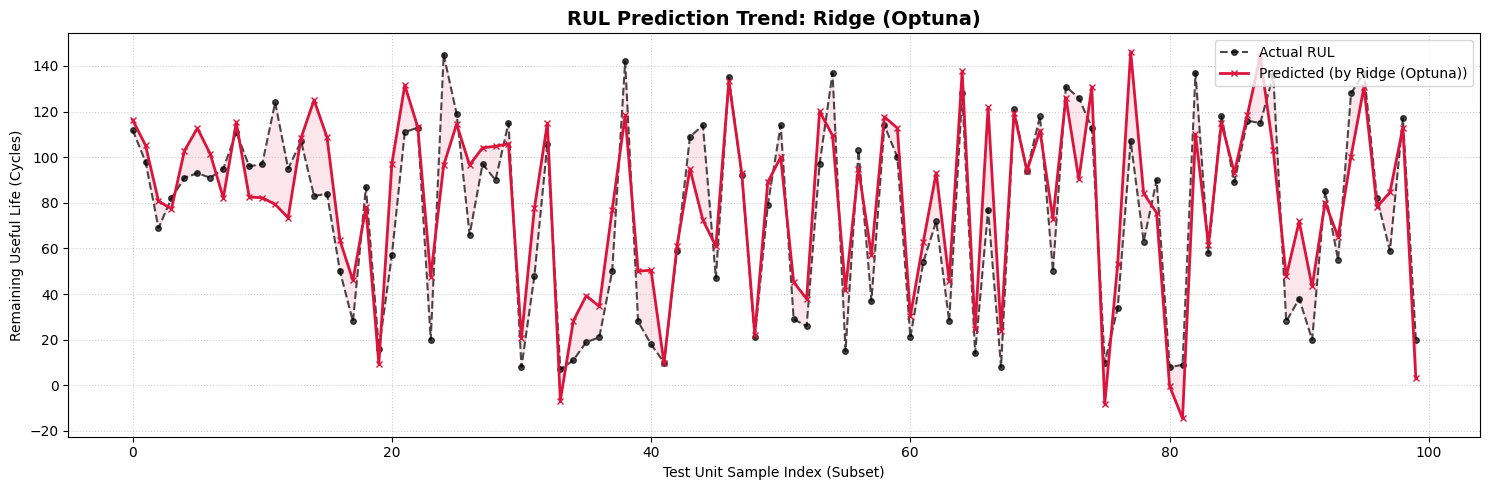

  [Lasso] Optuna 최적화 중... 

[I 2026-04-24 11:33:14,064] A new study created in memory with name: no-name-45bf5f6a-94a3-4971-bc22-8f5b18d01d05
c:\python_course\4project_cmapss\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.233e+03, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(
[I 2026-04-24 11:37:40,548] Trial 0 finished with value: 17.205847660221693 and parameters: {'alpha': 0.0074593432857265485}. Best is trial 0 with value: 17.205847660221693.
[I 2026-04-24 11:37:40,621] Trial 1 finished with value: 37.56381259428765 and parameters: {'alpha': 5.669849511478847}. Best is trial 0 with value: 17.205847660221693.
[I 2026-04-24 11:37:47,724] Trial 2 finished with value: 20.446538985243443 and parameters: {'alpha': 0.4570563099801455}. Best is trial 0 with value: 17.205847660221693.
[I 202


 [Lasso (Optuna)] 모델 평가 결과
-------------------------------------------------------
 RMSE       : 19.9210
 NASA Score : 765.4156


c:\python_course\4project_cmapss\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.584e+06, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(


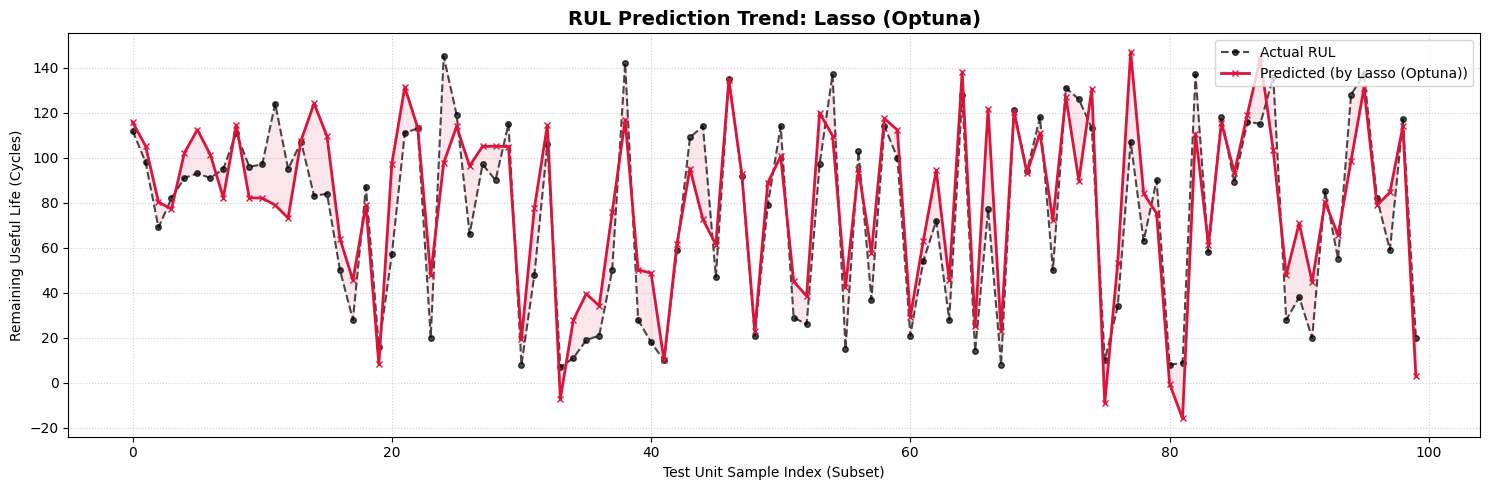

  [ElasticNet] Optuna 최적화 중... 

[I 2026-04-24 12:32:37,465] A new study created in memory with name: no-name-4e776711-b146-41b7-82ef-eee0e4dfe740
c:\python_course\4project_cmapss\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.626e+05, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(
[I 2026-04-24 12:38:00,385] Trial 0 finished with value: 17.476493729438513 and parameters: {'alpha': 0.0074593432857265485, 'l1_ratio': 0.9056428757689245}. Best is trial 0 with value: 17.476493729438513.
[I 2026-04-24 12:38:03,884] Trial 1 finished with value: 21.263851904817635 and parameters: {'alpha': 0.4570563099801455, 'l1_ratio': 0.588792635777333}. Best is trial 0 with value: 17.476493729438513.
c:\python_course\4project_cmapss\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: Conver


 [ElasticNet (Optuna)] 모델 평가 결과
-------------------------------------------------------
 RMSE       : 20.5700
 NASA Score : 826.6584


c:\python_course\4project_cmapss\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.227e+06, tolerance: 2.874e+03
  model = cd_fast.enet_coordinate_descent(


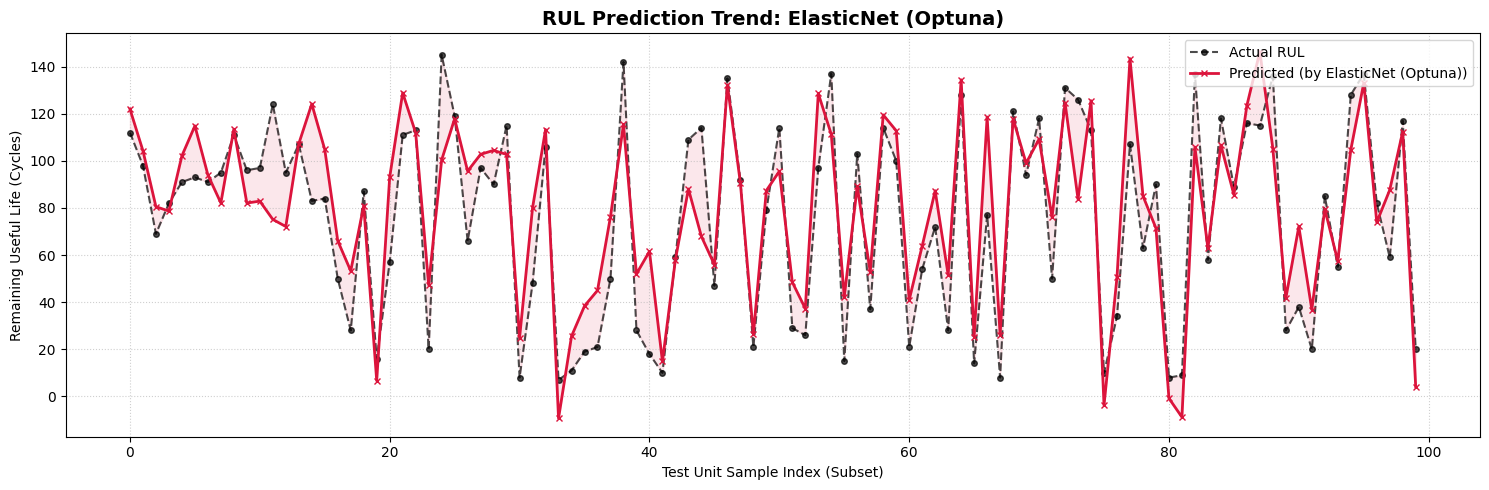


=== 5. 트리 모델 학습 (Optuna) ===
피처 수: 185개 | Trials: 30

  [RandomForest] Optuna 최적화 중... 

[I 2026-04-24 13:41:45,757] A new study created in memory with name: no-name-848b4d41-1192-4937-9a55-9b22e3679ac0
[I 2026-04-24 13:42:10,418] Trial 0 finished with value: 15.214416361136804 and parameters: {'n_estimators': 175, 'max_depth': 29, 'min_samples_split': 15}. Best is trial 0 with value: 15.214416361136804.
[I 2026-04-24 13:42:29,980] Trial 1 finished with value: 15.320520330944404 and parameters: {'n_estimators': 220, 'max_depth': 9, 'min_samples_split': 4}. Best is trial 0 with value: 15.214416361136804.
[I 2026-04-24 13:42:46,250] Trial 2 finished with value: 15.196443588544973 and parameters: {'n_estimators': 111, 'max_depth': 27, 'min_samples_split': 13}. Best is trial 2 with value: 15.196443588544973.
[I 2026-04-24 13:42:59,144] Trial 3 finished with value: 16.16883340880887 and parameters: {'n_estimators': 242, 'max_depth': 5, 'min_samples_split': 20}. Best is trial 2 with value: 15.196443588544973.
[I 2026-04-24 13:43:24,536] Trial 4 finished with value: 15.2301855649


 [RandomForest (Optuna)] 모델 평가 결과
-------------------------------------------------------
 RMSE       : 18.9399
 NASA Score : 656.2319


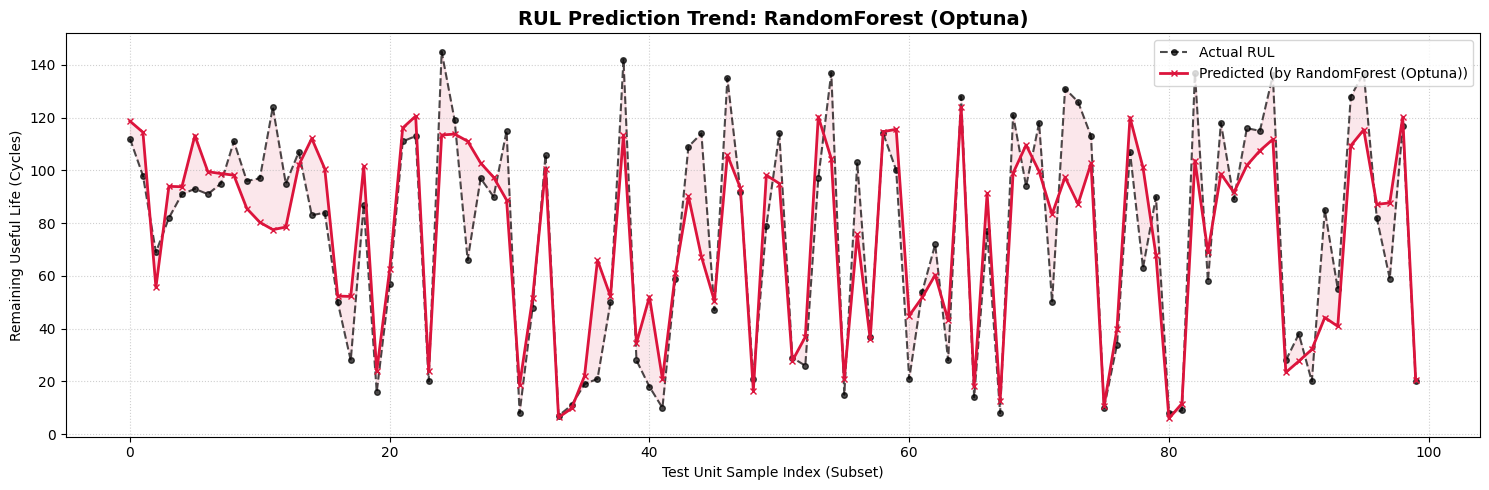

  [XGBoost] Optuna 최적화 중... 

[I 2026-04-24 13:56:29,487] A new study created in memory with name: no-name-d10131ba-e96d-4bcb-b2b0-9c4f39839cc3
[I 2026-04-24 13:56:41,978] Trial 0 finished with value: 15.207889637506003 and parameters: {'n_estimators': 287, 'max_depth': 10, 'learning_rate': 0.1205712628744377}. Best is trial 0 with value: 15.207889637506003.
[I 2026-04-24 13:56:43,174] Trial 1 finished with value: 14.715306747925673 and parameters: {'n_estimators': 399, 'max_depth': 4, 'learning_rate': 0.01699897838270077}. Best is trial 1 with value: 14.715306747925673.
[I 2026-04-24 13:56:48,262] Trial 2 finished with value: 14.960803891374683 and parameters: {'n_estimators': 129, 'max_depth': 9, 'learning_rate': 0.07725378389307355}. Best is trial 1 with value: 14.715306747925673.
[I 2026-04-24 13:56:49,387] Trial 3 finished with value: 15.54019122581704 and parameters: {'n_estimators': 454, 'max_depth': 3, 'learning_rate': 0.2708160864249968}. Best is trial 1 with value: 14.715306747925673.
[I 2026-04-24 13:56:


 [XGBoost (Optuna)] 모델 평가 결과
-------------------------------------------------------
 RMSE       : 17.4062
 NASA Score : 492.8104


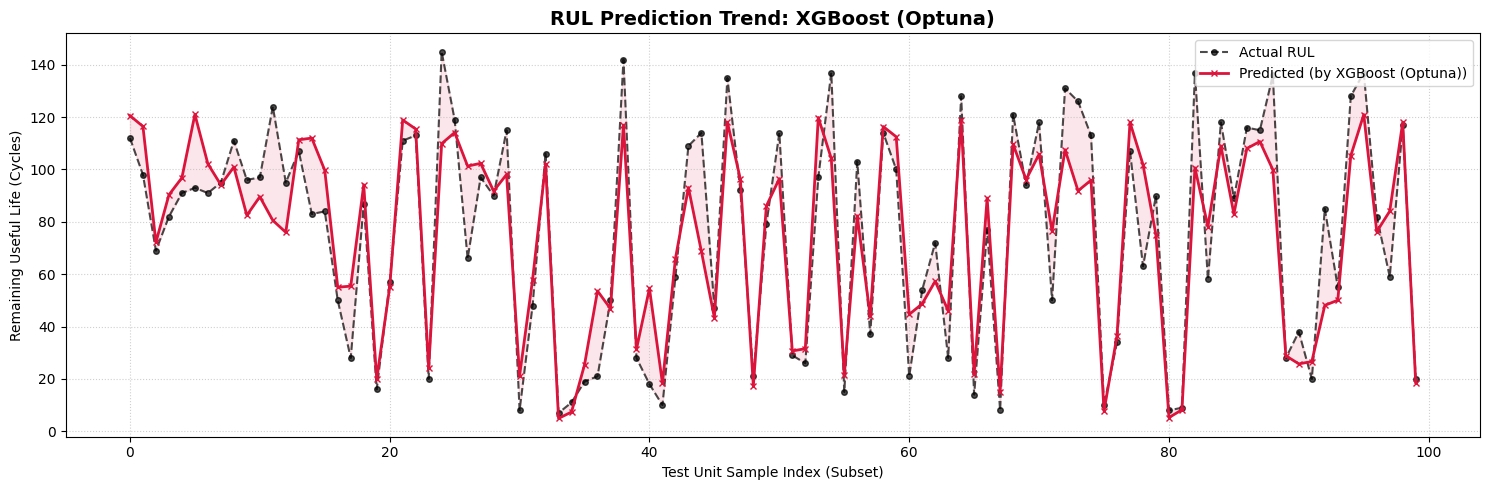

  [LightGBM] Optuna 최적화 중... 

[I 2026-04-24 13:57:43,768] A new study created in memory with name: no-name-2fa36aa0-f064-4c16-b1d5-894ce578fd29
[I 2026-04-24 13:57:45,796] Trial 0 finished with value: 15.064433688496461 and parameters: {'n_estimators': 287, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'num_leaves': 128}. Best is trial 0 with value: 15.064433688496461.
[I 2026-04-24 13:57:46,103] Trial 1 finished with value: 16.316317880018683 and parameters: {'n_estimators': 178, 'max_depth': 4, 'learning_rate': 0.012184186502221764, 'num_leaves': 176}. Best is trial 0 with value: 15.064433688496461.
[I 2026-04-24 13:57:50,215] Trial 2 finished with value: 14.86371518143936 and parameters: {'n_estimators': 401, 'max_depth': 10, 'learning_rate': 0.010725209743171996, 'num_leaves': 195}. Best is trial 2 with value: 14.86371518143936.
[I 2026-04-24 13:57:51,129] Trial 3 finished with value: 14.53682023838836 and parameters: {'n_estimators': 517, 'max_depth': 5, 'learning_rate': 0.01855998084649059, 'num_leave


 [LightGBM (Optuna)] 모델 평가 결과
-------------------------------------------------------
 RMSE       : 18.6780
 NASA Score : 602.1394


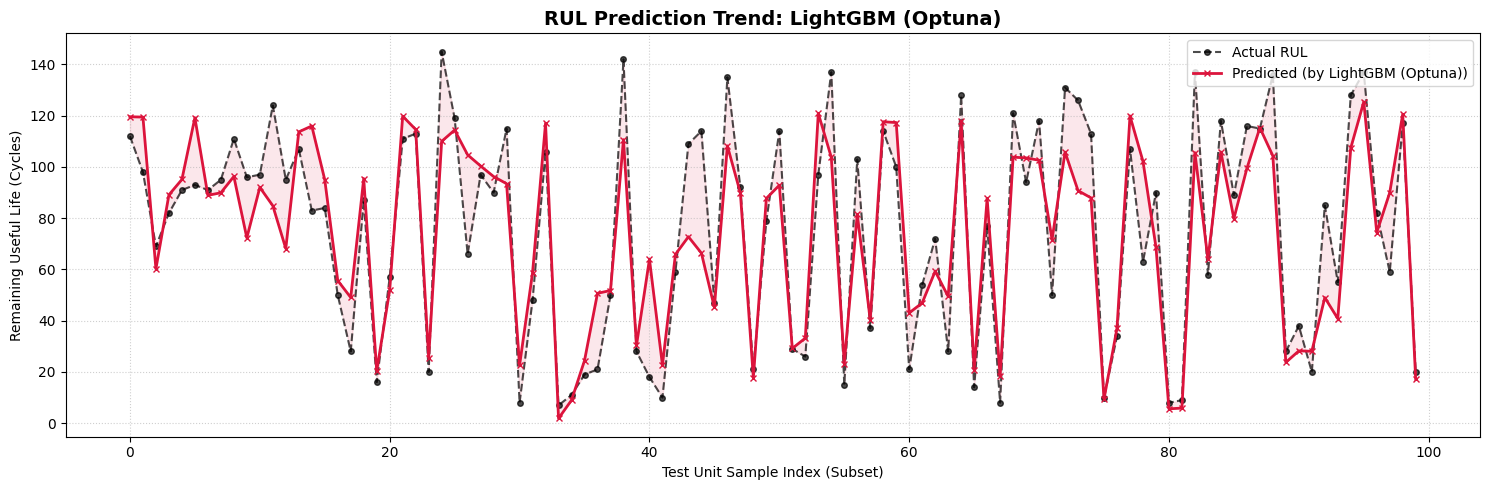

In [5]:
# [사전 설정] 전처리 결과 연결
# FEATURES_LINEAR와 FEATURES_TREE를 동일하게 X_features_full로 사용하거나 
# 필요시 분리해서 정의
FEATURES_LINEAR = X_features_full 
FEATURES_TREE = X_features_full

# 하이퍼파라미터
N_TRIALS_LIN = 15
N_TRIALS_TRE = 30 

# ---------------------------------------------------------
# 4. 선형 모델 학습 (Optuna)
# ---------------------------------------------------------
print(f'=== 4. 선형 모델 학습 (Optuna) ===')
print(f'피처 수: {len(FEATURES_LINEAR)}개 | Trials: {N_TRIALS_LIN}\n')

def get_linear_model(trial, name):
    if name == 'Ridge':
        return Ridge(alpha=trial.suggest_float('alpha', 0.01, 500, log=True), 
                     random_state=CONFIG['RANDOM_STATE'])
    elif name == 'Lasso':
        return Lasso(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True), 
                     max_iter=10000, random_state=CONFIG['RANDOM_STATE'])
    else:  # ElasticNet
        return ElasticNet(
            alpha=trial.suggest_float('alpha', 1e-4, 10, log=True),
            l1_ratio=trial.suggest_float('l1_ratio', 0.05, 0.95),
            max_iter=10000, random_state=CONFIG['RANDOM_STATE'])

linear_models = ['Ridge', 'Lasso', 'ElasticNet']
linear_results = {}

for mname in linear_models:
    t0 = time.time()
    print(f'  [{mname}] Optuna 최적화 중... ', end='', flush=True)

    def objective(trial):
        model = get_linear_model(trial, mname)
        model.fit(X_train[FEATURES_LINEAR], y_train)
        # 검증셋(X_val) 기준으로 점수 최적화 ㅋ
        preds = model.predict(X_val[FEATURES_LINEAR])
        return np.sqrt(mean_squared_error(y_val, preds))

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=CONFIG['RANDOM_STATE']))
    study.optimize(objective, n_trials=N_TRIALS_LIN)

    # 최적 파라미터로 최종 학습
    best_p = study.best_params
    best_m = get_linear_model(optuna.trial.FixedTrial(best_p), mname)
    best_m.fit(X_train[FEATURES_LINEAR], y_train)

    # 평가
    rmse, score = report_performance(y_test, best_m.predict(X_test[FEATURES_LINEAR]), f"{mname} (Optuna)")
    linear_results[mname] = {'rmse': rmse, 'score': score, 'time': time.time()-t0}

# ---------------------------------------------------------
# 5. 트리 모델 학습 (Optuna)
# ---------------------------------------------------------
print(f'\n=== 5. 트리 모델 학습 (Optuna) ===')
print(f'피처 수: {len(FEATURES_TREE)}개 | Trials: {N_TRIALS_TRE}\n')

def get_tree_model(trial, name):
    if name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=trial.suggest_int('n_estimators', 100, 300),
            max_depth=trial.suggest_int('max_depth', 5, 30),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
            random_state=CONFIG['RANDOM_STATE'], n_jobs=-1)
    elif name == 'XGBoost':
        return xgb.XGBRegressor(
            n_estimators=trial.suggest_int('n_estimators', 100, 600),
            max_depth=trial.suggest_int('max_depth', 3, 10),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            tree_method='hist', random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, verbosity=0)
    else:  # LightGBM
        return lgb.LGBMRegressor(
            n_estimators=trial.suggest_int('n_estimators', 100, 600),
            max_depth=trial.suggest_int('max_depth', 3, 12),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            num_leaves=trial.suggest_int('num_leaves', 20, 200),
            random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, verbose=-1)

tree_models = ['RandomForest', 'XGBoost', 'LightGBM']
tree_results = {}

for mname in tree_models:
    t0 = time.time()
    print(f'  [{mname}] Optuna 최적화 중... ', end='', flush=True)

    def objective(trial):
        model = get_tree_model(trial, mname)
        model.fit(X_train[FEATURES_TREE], y_train)
        preds = model.predict(X_val[FEATURES_TREE])
        return np.sqrt(mean_squared_error(y_val, preds))

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=CONFIG['RANDOM_STATE']))
    study.optimize(objective, n_trials=N_TRIALS_TRE)

    # 최적 파라미터로 최종 학습
    best_p = study.best_params
    if mname == 'RandomForest':
        best_m = RandomForestRegressor(**best_p, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1)
    elif mname == 'XGBoost':
        best_m = xgb.XGBRegressor(**best_p, tree_method='hist', random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, verbosity=0)
    else:
        best_m = lgb.LGBMRegressor(**best_p, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, verbose=-1)
    
    best_m.fit(X_train[FEATURES_TREE], y_train)

    # 평가 및 시각화 ㅋ
    rmse, score = report_performance(y_test, best_m.predict(X_test[FEATURES_TREE]), f"{mname} (Optuna)")
    tree_results[mname] = {'rmse': rmse, 'score': score, 'time': time.time()-t0}